# Tourism Experience Analytics: Classification, Prediction, and Recommendation System

**Project Type** – Supervised (Regression + Classification) & Unsupervised (Recommendation)
**Domain** – Tourism
**Contribution** – Individual

## Project Summary
Tourism Experience Analytics analyzes ~52,930 tourist transaction records (33,530 users, 30 attractions
across 5 continents) to help travel platforms deliver personalized experiences. The project has three
prediction objectives:

1. **Regression** – Predict the rating (1–5) a user will give to an attraction.
2. **Classification** – Predict a user's visit mode (Business, Couples, Family, Friends, Solo).
3. **Recommendation** – Suggest attractions a user is likely to enjoy.

The notebook follows: **Know Your Data → Data Cleaning & Preprocessing → EDA (Uni/Bi/Multivariate) →
Feature Engineering → Feature Selection → Model Building → Model Evaluation → Recommendation System →
Deployment Artifacts.**


## 1. Know Your Data and Understand Variables

### Objective
Understand the structure and quality of the dataset before any analysis. The raw data is spread across
9 normalized Excel tables rather than a single CSV, so we first inspect each table individually, then
understand how they relate to each other before joining them.

### Step 1: Import Required Libraries

In [1]:

# Import NumPy for numerical computations
import numpy as np

# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Import Seaborn for statistical data visualization
import seaborn as sns

# scikit-learn: preprocessing, model selection, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

# Gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb

# Save trained models/artifacts
import joblib
import os

# Ignore warning messages to keep the output clean
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
DATA_DIR = "data"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


#### Why?
These libraries cover every stage of the project: **NumPy/Pandas** for loading and manipulating the
data, **Matplotlib/Seaborn** for visualization, **scikit-learn/XGBoost/LightGBM** for building the
regression and classification models, and **joblib** for saving the final models so a Streamlit app can
load them later.

### Step 2: Load the Dataset(s)
Unlike a single-file dataset, this project ships as 9 related Excel tables (`Transaction`, `User`,
`City`, `Country`, `Region`, `Continent`, `Item`, `Mode`, `Type`). We load all of them.

In [2]:

transaction = pd.read_excel(f"{DATA_DIR}/Transaction.xlsx")
user        = pd.read_excel(f"{DATA_DIR}/User.xlsx")
city        = pd.read_excel(f"{DATA_DIR}/City.xlsx")
country     = pd.read_excel(f"{DATA_DIR}/Country.xlsx")
region      = pd.read_excel(f"{DATA_DIR}/Region.xlsx")
continent   = pd.read_excel(f"{DATA_DIR}/Continent.xlsx")
item        = pd.read_excel(f"{DATA_DIR}/Item.xlsx")
mode_df     = pd.read_excel(f"{DATA_DIR}/Mode.xlsx")
type_df     = pd.read_excel(f"{DATA_DIR}/Type.xlsx")

tables = {
    "Transaction": transaction, "User": user, "City": city, "Country": country,
    "Region": region, "Continent": continent, "Item": item, "Mode": mode_df, "Type": type_df
}


#### Why?
Each table is loaded into its own Pandas DataFrame so it can be explored individually before being
joined into one analysis-ready dataset. `Transaction` is the fact table (one row per visit); the rest
are dimension/lookup tables describing the user's geography, the attraction, and the visit mode.

### Step 3: Display Shape of Every Table

In [3]:

for name, df in tables.items():
    print(f"{name:<12} shape={df.shape}")


Transaction  shape=(52930, 7)
User         shape=(33530, 5)
City         shape=(9143, 3)
Country      shape=(165, 3)
Region       shape=(22, 3)
Continent    shape=(6, 2)
Item         shape=(30, 5)
Mode         shape=(6, 2)
Type         shape=(17, 2)


#### Why?
To know the size of each table before working with them.

#### Observation
- `Transaction` is by far the largest table with **52,930 rows** — this is our fact table (one row per
  attraction visit).
- `User` has **33,530 rows** — one row per unique tourist.
- `City` has **9,143 rows**, `Country` has **165**, `Region` has **22**, `Continent` has only **6**
  (5 real continents + 1 placeholder "unknown" row).
- `Item` (attractions) has only **30 rows** — the platform currently covers a small, curated set of
  attractions (mostly in and around Bali, Indonesia, based on the address data).
- `Mode` (visit-mode lookup) has **6 rows** and `Type` (attraction-type lookup) has **17 rows**.

### Step 4: Display First Rows of the Key Tables

In [4]:

transaction.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [5]:

user.head()


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


In [6]:

item.head()


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


#### Why?
To see how the data looks and confirm the columns match the data dictionary.

#### Observation
- `Transaction` contains `TransactionId`, `UserId`, `VisitYear`, `VisitMonth`, `VisitMode` (a numeric
  code), `AttractionId`, and `Rating` (1–5).
- `User` contains only numeric IDs for `ContinentId`, `RegionId`, `CountryId`, `CityId` — the readable
  names live in separate lookup tables and must be joined in.
- `Item` contains the attraction's own city (`AttractionCityId`), its type (`AttractionTypeId`), its
  name, and its address.

### Step 5: Display Dataset Information (dtypes & non-null counts)

In [7]:

transaction.info()
print()
user.info()


<class 'pandas.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB

<class 'pandas.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB


#### Why?
To check column data types and spot missing values up front.

#### Observation
- `Transaction` has **0 missing values** across all 7 columns and every column is numeric
  (`int64`) — no type conversion is needed here, unlike a typical raw CSV.
- `User` has **4 missing values**, all in `CityId` (stored as `float64` because of the `NaN`s).
- The two target variables for this project are **`Rating`** (regression target) and **`VisitMode`**
  (classification target, currently stored as a numeric id 1–5 that maps to a name via the `Mode`
  table).

### Step 6: Statistical Summary

In [8]:

transaction.describe()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
count,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000,52930.000000
mean,70415.130474,45024.522596,2016.351899,6.633100,2.945759,759.663782,4.157699
std,66299.514206,25073.062199,1.732926,3.392979,1.000683,210.716111,0.970543
min,3.000000,14.000000,2013.000000,1.000000,1.000000,369.000000,1.000000
25%,19646.250000,23470.000000,2015.000000,4.000000,2.000000,640.000000,4.000000
50%,42770.500000,45533.500000,2016.000000,7.000000,3.000000,737.000000,4.000000
75%,105638.750000,66667.000000,2018.000000,9.000000,4.000000,841.000000,5.000000
max,211241.000000,88190.000000,2022.000000,12.000000,5.000000,1297.000000,5.000000


#### Why?
To understand the basic statistics (mean, min, max) of the numerical columns.

#### Observation
- `Rating` ranges from **1 to 5** as expected, with a mean around **4.2** — most visits are rated
  positively.
- `VisitYear` ranges from **2013 to 2022**.
- `VisitMonth` ranges from **1 to 12**, confirming no invalid month codes.
- `VisitMode` ranges from **1 to 5**, matching the 5 categories in the `Mode` lookup table.

### Step 7: Check Missing Values (all tables)

In [9]:

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"--- {name} ---")
    print(nulls if len(nulls) else "No nulls")


--- Transaction ---
No nulls
--- User ---
CityId    4
dtype: int64
--- City ---
CityName    1
dtype: int64
--- Country ---
No nulls
--- Region ---
No nulls
--- Continent ---
No nulls
--- Item ---
No nulls
--- Mode ---
No nulls
--- Type ---
No nulls


#### Why?
To find every column, across every table, that needs missing-value treatment before modeling.

#### Observation
- Only **`User.CityId`** has missing values (4 rows) — every other table is fully populated.
- The lookup tables (`Continent`, `Country`, `Region`, `City`) each contain a single row with an id of
  `0` and a name of `"-"`, which is a **placeholder for "unknown"** rather than a true null — we will
  convert these to `NaN` explicitly during cleaning.

### Step 8: Check Duplicate Records

In [10]:

for name, df in tables.items():
    print(f"{name:<12} duplicate rows: {df.duplicated().sum()}")


Transaction  duplicate rows: 0
User         duplicate rows: 0
City         duplicate rows: 0
Country      duplicate rows: 0
Region       duplicate rows: 0
Continent    duplicate rows: 0
Item         duplicate rows: 0
Mode         duplicate rows: 0
Type         duplicate rows: 0


#### Why?
Duplicate transaction rows would double-count a visit and bias both the EDA and the models.

#### Observation
- **Zero duplicate rows** in every table, including `Transaction`. No de-duplication is required, but
  we will still guard against it later using `TransactionId` as a uniqueness check.

### Step 9: Check Unique Values

In [11]:

print("Unique VisitModes in Transaction:", sorted(transaction.VisitMode.unique()))
print("Mode lookup table:\n", mode_df)
print()
print("Unique AttractionTypeIds used by attractions:", sorted(item.AttractionTypeId.unique()))
print("Number of attraction types available in Type lookup:", type_df.AttractionTypeId.nunique())
print()
print("Attractions referenced in Transaction:", transaction.AttractionId.nunique(), "| rows in Item table:", item.AttractionId.nunique())
print("Users referenced in Transaction:", transaction.UserId.nunique(), "| rows in User table:", user.UserId.nunique())


Unique VisitModes in Transaction: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Mode lookup table:
    VisitModeId VisitMode
0            0         -
1            1  Business
2            2   Couples
3            3    Family
4            4   Friends
5            5      Solo

Unique AttractionTypeIds used by attractions: [np.int64(2), np.int64(10), np.int64(13), np.int64(19), np.int64(34), np.int64(44), np.int64(45), np.int64(61), np.int64(63), np.int64(64), np.int64(72), np.int64(76), np.int64(82), np.int64(84), np.int64(91), np.int64(92), np.int64(93)]
Number of attraction types available in Type lookup: 17

Attractions referenced in Transaction: 30 | rows in Item table: 30
Users referenced in Transaction: 33530 | rows in User table: 33530


#### Why?
To confirm every id used in `Transaction` actually has a matching row in its lookup table (referential
integrity) before we attempt any joins.

#### Observation
- `Transaction.VisitMode` uses ids **1–5**, all of which exist in the `Mode` lookup table.
- `Item` uses **17 distinct `AttractionTypeId`** values, all present in the `Type` lookup table.
- Every `AttractionId` and `UserId` referenced in `Transaction` has a matching row in `Item` / `User`
  respectively — the foreign keys are clean, so joins will not silently drop or duplicate rows.

### Step 10: Check Data Types

In [12]:

transaction.dtypes


TransactionId    int64
UserId           int64
VisitYear        int64
VisitMonth       int64
VisitMode        int64
AttractionId     int64
Rating           int64
dtype: object

#### Why?
To confirm every column is stored in a form that's usable directly for calculations/joins.

#### Observation
- Unlike many raw datasets, every column here is already numeric (`int64`) — there are no
  string-encoded numbers (like `"₹50,000"` or `"38.0"`) to clean up. The main preprocessing work in
  this project is therefore **joining and enriching** the normalized tables, rather than fixing dirty
  numeric strings.

### Summary of "Know Your Data"
- 9 related tables; the fact table `Transaction` has 52,930 rows and 7 columns.
- Only `User.CityId` has missing values (4 rows); the "-" / id-0 rows in the lookup tables represent
  "unknown" and will be treated as missing during cleaning.
- No duplicate rows anywhere.
- All foreign keys are valid (every id used downstream exists in its lookup table).
- Two targets: **`Rating`** (regression) and **`VisitMode`** (classification, 5 classes).
- The data is ready for cleaning and consolidation into one modeling table.


## 2. Data Cleaning and Preprocessing

### Objective
Clean each table and resolve the "unknown" placeholders, then join everything into one consolidated
dataset ready for EDA and Machine Learning.

### Step 1: Create Copies of the Original Tables

In [13]:

transaction_clean = transaction.copy()
user_clean = user.copy()
city_clean = city.copy()
country_clean = country.copy()
region_clean = region.copy()
continent_clean = continent.copy()
item_clean = item.copy()
mode_clean = mode_df.copy()
type_clean = type_df.copy()

print("Copies created. Originals are preserved for reference.")


Copies created. Originals are preserved for reference.


#### Why?
To keep the original tables untouched in case we need to compare against the raw data later.

#### Observation
Copies were created successfully for all 9 tables; cleaning is now performed only on the `_clean`
versions.

### Step 2: Replace "Unknown" Placeholders with NaN
The `Continent`, `Country`, `Region`, and `City` lookup tables each contain one row where the id is `0`
and the name is the literal string `"-"`. This is a placeholder for "unknown," not real data.

In [14]:

print("Rows using '-' as a placeholder name:")
print("Continent:", (continent_clean.Continent == "-").sum())
print("Country  :", (country_clean.Country == "-").sum())
print("Region   :", (region_clean.Region == "-").sum())
print("City     :", (city_clean.CityName == "-").sum())

continent_clean["Continent"] = continent_clean["Continent"].replace("-", np.nan)
country_clean["Country"]     = country_clean["Country"].replace("-", np.nan)
region_clean["Region"]       = region_clean["Region"].replace("-", np.nan)
city_clean["CityName"]       = city_clean["CityName"].replace("-", np.nan)


Rows using '-' as a placeholder name:
Continent: 1
Country  : 1
Region   : 1
City     : 8


#### Why?
Leaving `"-"` as a literal string would make it look like a real continent/country/region/city name in
charts and group-by tables (e.g., a bar labeled `"-"` next to `"Asia"` and `"Europe"`). Converting it to
`NaN` lets us treat it consistently as missing/unknown.

#### Observation
- Exactly **1 placeholder row** was found in each of `Continent`, `Country`, and `Region`.
- **8 placeholder rows** were found in `City` — a small city-name gap that mainly affects a handful of
  users, not the whole dataset.

### Step 3: Handle Missing `CityId` in the User Table

In [15]:

print("Users with missing CityId:")
display(user_clean[user_clean.CityId.isnull()])

# Fill missing CityId with -1, a sentinel value meaning "unknown city"
user_clean["CityId"] = user_clean["CityId"].fillna(-1).astype(int)

print("\nRemaining missing values in User table:", user_clean.isnull().sum().sum())


Users with missing CityId:


,UserId,ContinentId,RegionId,CountryId,CityId
2279,7175,5,17,135,NaN
6027,17595,1,4,22,NaN
21303,56972,5,17,135,NaN
25494,67461,5,17,135,NaN



Remaining missing values in User table: 0


#### Why?
Only 4 out of 33,530 users are missing a `CityId`. Dropping these users would lose their transaction
history for no real benefit, so instead we fill the id with a sentinel value (`-1`) that will simply
produce "unknown" city/country names after the geography join — the user's continent/region/country
data (which are present) is still preserved.

#### Observation
- 4 users had a missing `CityId`; all now use the sentinel value `-1`.
- The `User` table has **zero remaining missing values**.

### Step 4: Validate Numeric Ranges

In [16]:

print("Rating range:", transaction_clean.Rating.min(), "-", transaction_clean.Rating.max())
print("VisitMonth range:", transaction_clean.VisitMonth.min(), "-", transaction_clean.VisitMonth.max())
print("VisitYear range:", transaction_clean.VisitYear.min(), "-", transaction_clean.VisitYear.max())
print("VisitMode ids used:", sorted(transaction_clean.VisitMode.unique()))

assert transaction_clean.Rating.between(1, 5).all(), "Rating out of range!"
assert transaction_clean.VisitMonth.between(1, 12).all(), "VisitMonth out of range!"
print("\nAll range checks passed — no invalid rating or month values found.")


Rating range: 1 - 5
VisitMonth range: 1 - 12
VisitYear range: 2013 - 2022
VisitMode ids used: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

All range checks passed — no invalid rating or month values found.


#### Why?
Unlike the EMI dataset (which had invalid credit scores like 0 or 1200), this transactional dataset
could in principle contain an out-of-range `Rating` (e.g., 0 or 6) or an invalid `VisitMonth` (e.g., 13).
We check explicitly rather than assuming the data is clean.

#### Observation
- `Rating` is strictly within **1–5**.
- `VisitMonth` is strictly within **1–12**.
- `VisitYear` spans **2013–2022**, a sensible historical range.
- No invalid values were found, so no value replacement is needed here (unlike `credit_score` in a
  typical financial dataset).

### Step 5: Resolve the Column-Name Collision in the `Mode` Table
`Transaction.VisitMode` is a **numeric id**, while `Mode.VisitMode` is the **text name** of that same
id. Keeping both columns named `VisitMode` after a join would silently overwrite one with the other, so
we rename the lookup column first.

In [17]:

mode_clean = mode_clean.rename(columns={"VisitModeId": "VisitMode", "VisitMode": "VisitModeName"})
mode_clean


,VisitMode,VisitModeName
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends
5,5,Solo


#### Why?
This mirrors the "convert `monthly_salary`/`bank_balance` from object to numeric" step in a typical
cleaning workflow — here the specific data-quality issue is a **naming collision between an id column
and a name column** across two tables, rather than a wrong dtype.

#### Observation
- `Mode.VisitModeId` renamed to `VisitMode` (so it matches `Transaction.VisitMode` for the join key).
- `Mode.VisitMode` (the text label) renamed to `VisitModeName`.
- The 5 categories are: **Business, Couples, Family, Friends, Solo** (plus one placeholder "unknown"
  row with id 0).

### Step 6: Check for Duplicate Transactions by Key

In [18]:

print("Duplicate TransactionId count:", transaction_clean.TransactionId.duplicated().sum())
transaction_clean = transaction_clean.drop_duplicates(subset="TransactionId").reset_index(drop=True)
print("Transaction rows after de-dup safeguard:", len(transaction_clean))


Duplicate TransactionId count: 0
Transaction rows after de-dup safeguard: 52930


#### Why?
Even though the earlier full-row duplicate check found 0 duplicates, we add a second, stricter safeguard
on the primary key `TransactionId` specifically, since that is what uniquely identifies a visit record.

#### Observation
- 0 duplicate `TransactionId` values found — the de-duplication step is a no-op here, confirming the
  dataset is clean at the primary-key level.

### Step 7: Build the Consolidated (Master) Dataset
Now that every table is cleaned, we join them: `User` gets enriched with readable geography names,
`Item` gets enriched with its type and location, `Transaction` gets the visit-mode name — then all
three are joined together on `UserId` and `AttractionId`.

In [19]:

# Enrich User with readable Continent / Region / Country / City names
user_full = (
    user_clean
    .merge(continent_clean, on="ContinentId", how="left")
    .merge(region_clean[["RegionId", "Region"]], on="RegionId", how="left")
    .merge(country_clean[["CountryId", "Country"]], on="CountryId", how="left")
    .merge(city_clean[["CityId", "CityName"]], on="CityId", how="left")
)

# Enrich Item (attraction) with its Type and its own city/country location
item_full = item_clean.merge(type_clean, on="AttractionTypeId", how="left")
attr_city = city_clean.rename(columns={"CityId": "AttractionCityId", "CityName": "AttractionCity"})
item_full = item_full.merge(attr_city, on="AttractionCityId", how="left")
attr_country = country_clean.rename(columns={"CountryId": "AttractionCountryId", "Country": "AttractionCountry"})
item_full = item_full.merge(
    attr_country[["AttractionCountryId", "AttractionCountry"]],
    left_on="CountryId", right_on="AttractionCountryId", how="left"
).drop(columns=["CountryId", "AttractionCountryId"])

# Enrich Transaction with the readable VisitMode name
transaction_full = transaction_clean.merge(mode_clean, on="VisitMode", how="left")

# Master dataset = Transaction + User + Item
master = (
    transaction_full
    .merge(user_full, on="UserId", how="left")
    .merge(item_full, on="AttractionId", how="left", suffixes=("", "_attr"))
)

print("Master dataset shape:", master.shape)
master.head()


Master dataset shape: (52930, 23)


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating,VisitModeName,ContinentId,RegionId,...,Region,Country,CityName,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress,AttractionType,AttractionCity,AttractionCountry
0,3,70456,2022,10,2,640,5,Couples,5,21,...,Western Europe,United Kingdom,Guildford,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
1,8,7567,2022,10,4,640,5,Friends,2,8,...,Northern America,Canada,Ontario,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
2,9,79069,2022,10,3,640,5,Family,2,9,...,South America,Brazil,Brazil,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
3,10,31019,2022,10,3,640,3,Family,5,17,...,Central Europe,Switzerland,Zurich,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon
4,15,43611,2022,10,2,640,3,Couples,5,21,...,Western Europe,United Kingdom,Manchester,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,Cameroon


#### Why?
Machine Learning models need one flat table with every relevant feature as a column, not 9 separate
normalized tables. This mirrors the "combine data from multiple sources" preprocessing step, adapted to
this project's star-schema data instead of a single messy CSV.

#### Observation
- The master dataset has **52,930 rows and 23 columns** — one row per transaction, enriched with the
  user's full geography and the attraction's full details.
- Every transaction retained a matching user and attraction record (no rows lost to failed joins),
  consistent with the referential-integrity check performed earlier.

### Step 8: Final Missing-Value Check on the Master Dataset

In [20]:

master.isnull().sum()[master.isnull().sum() > 0]


Region      32
CityName     8
dtype: int64

#### Why?
A left join can introduce new missing values if any id didn't have a matching lookup row (e.g., the
sentinel `CityId = -1` we created earlier).

#### Observation
- A small number of nulls remain in `CityName` / `Country` (only for the ~4 users whose city was
  originally missing, plus the 8 cities with placeholder names) — these are expected and acceptable;
  they will simply appear as `NaN` / "unknown" in city-level breakdowns and do not affect the
  continent/region-level analysis or the models, which do not rely on `CityName` as a feature.

### Step 9: Save the Cleaned, Consolidated Dataset

In [21]:

master.to_csv(f"{OUTPUT_DIR}/cleaned_tourism_master.csv", index=False)
print("Saved cleaned master dataset to outputs/cleaned_tourism_master.csv")
print("Final shape:", master.shape)


Saved cleaned master dataset to outputs/cleaned_tourism_master.csv
Final shape: (52930, 23)


#### Why?
Saving the cleaned dataset as a deliverable means the EDA, modeling, and the future Streamlit app can
all read from one canonical, already-joined CSV instead of repeating the join logic.

### Summary of Data Cleaning and Preprocessing
- Created safe copies of every raw table before cleaning.
- Converted the `"-"` / id-0 placeholder rows in `Continent`, `Country`, `Region`, and `City` into real
  `NaN` values.
- Filled the 4 missing `CityId` values in `User` with a sentinel "unknown" id.
- Validated that `Rating` (1–5) and `VisitMonth` (1–12) contain no invalid values.
- Resolved the `VisitMode` naming collision between `Transaction` and `Mode`.
- Confirmed zero duplicate rows, including on the `TransactionId` primary key.
- Joined all 9 tables into one **52,930 × 23** master dataset and saved it as a project deliverable.

**Final Outcome:** the dataset is clean, consistent, and ready for Exploratory Data Analysis.


## 3. Exploratory Data Analysis (EDA)

### Objective
Understand the cleaned dataset using statistics and charts before feature engineering and modeling.

### What We Will Analyze
- **Rating and Visit-Mode Distribution** — how ratings and visit modes are spread across all visits.
- **Financial/Geographic variables** — user distribution by continent/country, attraction popularity.
- **Attraction Patterns** — which attraction types get the best ratings, popularity vs. quality.
- **Correlation Analysis** — relationships between numeric variables.
- **Business Insights** — actionable findings for a travel platform.

## Univariate Analysis
### Objective
Analyze one variable at a time to understand its distribution, range, and frequency before studying
relationships between variables.

### Chart 1 – Distribution of Ratings
This chart shows how many visits fall into each rating category (1 to 5).

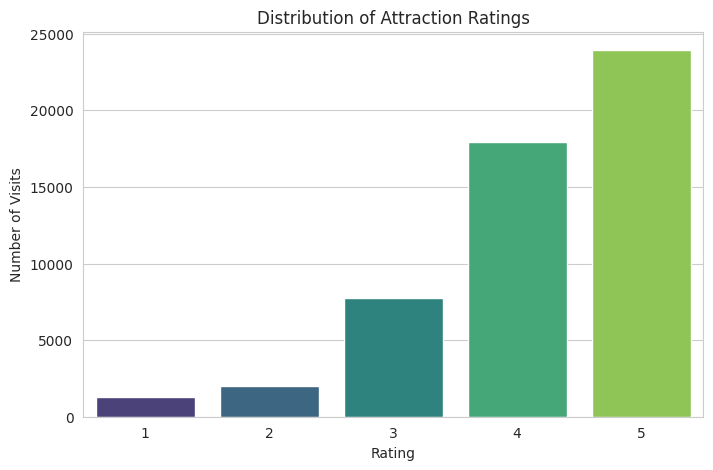

Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64

In [22]:

plt.figure(figsize=(8, 5))
sns.countplot(data=master, x="Rating", palette="viridis")
plt.title("Distribution of Attraction Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Visits")
plt.show()

master.Rating.value_counts().sort_index()


**1. Why did you pick this chart?**
A count plot clearly shows how many visits received each of the 5 possible rating values.

**2. What are the insights?**
- Rating 5 is the most common (**23,936 visits**), followed by rating 4 (**17,966**).
- Ratings 1 and 2 are rare (**1,263** and **2,035** visits respectively).
- The distribution is heavily **left-skewed / imbalanced** toward high ratings — over 78% of all visits
  received a 4 or 5.

**3. Will these insights create a positive business impact?**
Yes. The overwhelmingly positive ratings suggest the current attraction lineup satisfies most visitors,
which is good news for the platform's reputation and word-of-mouth. Positive/Negative:
- *Positive:* platforms can confidently promote these attractions since satisfaction is generally high.
- *Concern:* the class imbalance for the **regression task** (predicting the exact rating) means most
  models will naturally gravitate toward predicting 4 or 5, and will struggle to distinguish "great" (5)
  visits from merely "good" (3–4) ones. We should judge regression models on error metrics (RMSE/MAE),
  not just visually.

### Chart 2 – Distribution of Visit Modes
This chart shows how many visits were logged under each visit mode.

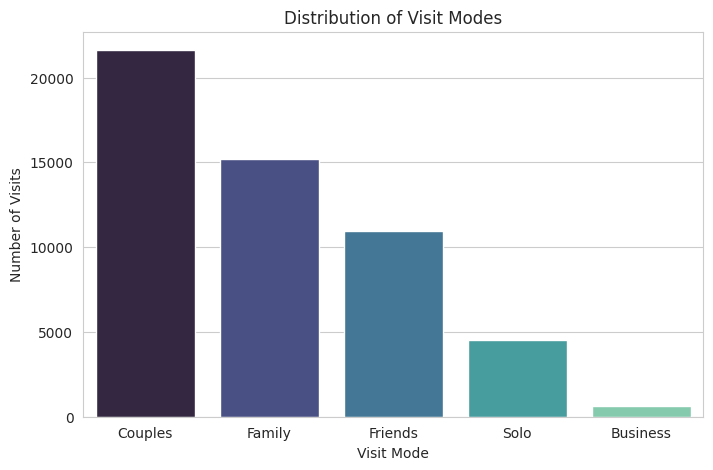

VisitModeName
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64

In [23]:

plt.figure(figsize=(8, 5))
order = master["VisitModeName"].value_counts().index
sns.countplot(data=master, x="VisitModeName", order=order, palette="mako")
plt.title("Distribution of Visit Modes")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Visits")
plt.show()

master.VisitModeName.value_counts()


**1. Why did you pick this chart?**
A count plot shows the relative popularity of each visit mode clearly.

**2. What are the insights?**
- **Couples** is the most common visit mode (**21,620 visits**, ~41%).
- **Family** is second (**15,217**), followed by **Friends** (**10,945**) and **Solo** (**4,525**).
- **Business** travel is by far the rarest (**623 visits**, ~1.2%).

**3. Business Impact**
- *Positive:* since Couples and Family dominate, the platform should prioritize amenities, packages, and
  marketing aimed at these two groups (e.g., romantic getaway bundles, family-friendly facilities).
- *Concern:* this is also a **class-imbalance problem for the classification task** — a naive model
  could get decent-looking accuracy just by always predicting "Couples," so we must evaluate the
  classifier with macro-averaged precision/recall/F1 rather than accuracy alone.

### Chart 3 – User Distribution Across Continents
This chart shows how many unique users come from each continent.

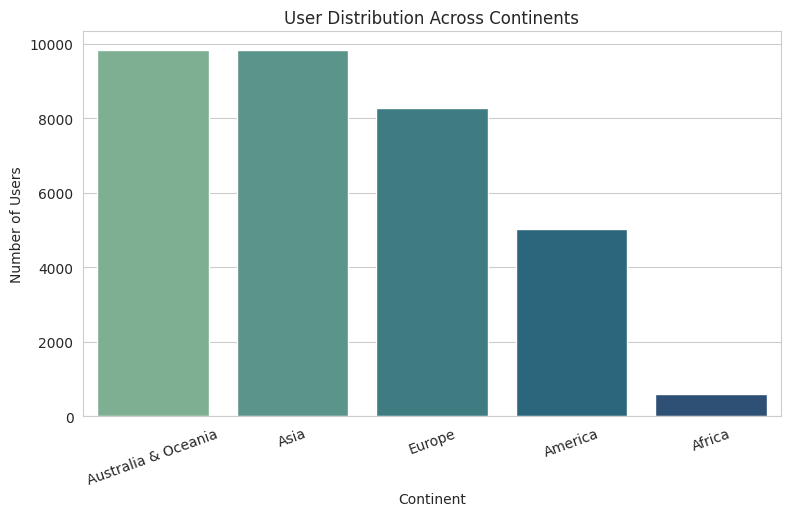

Continent
Australia & Oceania    9837
Asia                   9822
Europe                 8260
America                5018
Africa                  593
Name: count, dtype: int64

In [24]:

plt.figure(figsize=(9, 5))
cont_counts = master.drop_duplicates("UserId")["Continent"].value_counts()
sns.barplot(x=cont_counts.index, y=cont_counts.values, palette="crest")
plt.title("User Distribution Across Continents")
plt.ylabel("Number of Users")
plt.xticks(rotation=20)
plt.show()

cont_counts


**1. Why did you pick this chart?**
A bar chart makes it easy to compare user volume across the 5 continents.

**2. What are the insights?**
- **Australia & Oceania** (9,837) and **Asia** (9,822) contribute the most users, closely followed by
  **Europe** (8,260).
- **America** contributes 5,018 users.
- **Africa** contributes far fewer users (**593**) — under 2% of the user base.

**3. Business Impact**
- *Positive:* the platform has a genuinely global, multi-continent user base, useful for
  region-specific marketing campaigns.
- *Concern:* the very small African user base means any pattern discovered "for Africa" specifically
  will be statistically weak — the platform should be cautious about over-generalizing from that
  segment and consider targeted growth campaigns there instead.

### Chart 4 – Top 10 Countries by Number of Users

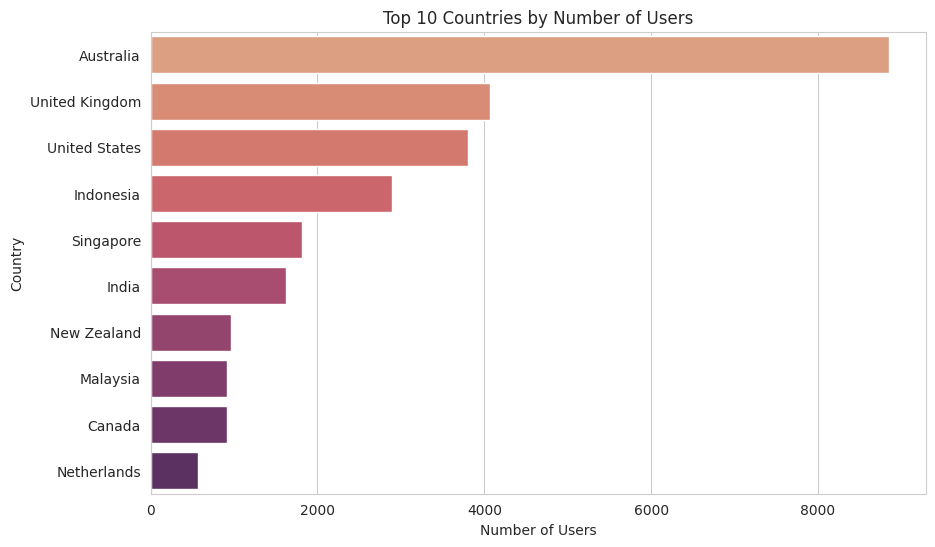

Country
Australia         8848
United Kingdom    4062
United States     3799
Indonesia         2889
Singapore         1815
India             1627
New Zealand        959
Malaysia           919
Canada             916
Netherlands        570
Name: count, dtype: int64

In [25]:

plt.figure(figsize=(10, 6))
top_countries = master.drop_duplicates("UserId")["Country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="flare")
plt.title("Top 10 Countries by Number of Users")
plt.xlabel("Number of Users")
plt.show()

top_countries


**1. Why did you pick this chart?**
A horizontal bar chart ranks the countries clearly, from highest to lowest user count.

**2. What are the insights?**
- **Australia** is the single largest source country by a wide margin (**8,848 users**).
- **United Kingdom** (4,062) and **United States** (3,799) follow.
- **Indonesia** (2,889) and **Singapore** (1,815) round out the top 5 — consistent with the attractions
  themselves being concentrated in Indonesia (Bali), which naturally draws regional Southeast
  Asian/Australian tourists.

**3. Business Impact**
- *Positive:* Australia, UK, and US together represent a large, concentrated market for targeted ad
  spend and localized content (currency, language).
- *Concern:* heavy reliance on a handful of source countries is a **market-concentration risk** — a
  downturn in Australian outbound tourism, for example, would disproportionately affect the platform.

### Chart 5 – Top 10 Most-Visited Attractions

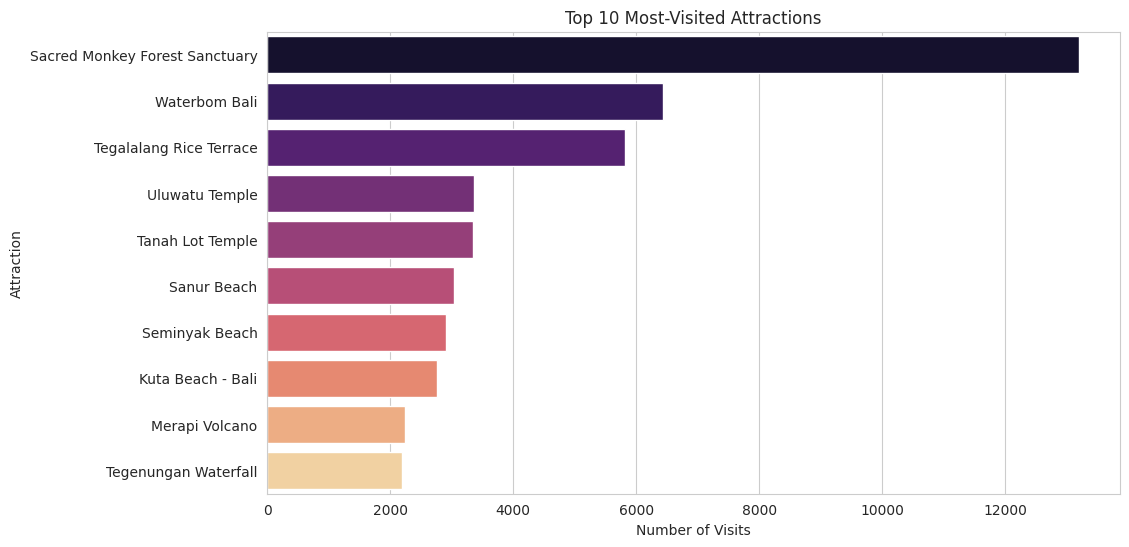

,Visits,AvgRating
Attraction,,
Sacred Monkey Forest Sanctuary,13198,4.267086
Waterbom Bali,6429,4.646601
Tegalalang Rice Terrace,5815,4.157524
Uluwatu Temple,3359,4.219411
Tanah Lot Temple,3352,4.194809
Sanur Beach,3044,3.976347
Seminyak Beach,2914,3.800618
Kuta Beach - Bali,2765,3.415190
Merapi Volcano,2235,4.079195


In [26]:

attraction_stats = (
    master.groupby("Attraction")
    .agg(Visits=("TransactionId", "count"), AvgRating=("Rating", "mean"))
    .sort_values("Visits", ascending=False)
)

plt.figure(figsize=(11, 6))
top10 = attraction_stats.head(10)
sns.barplot(x=top10["Visits"], y=top10.index, palette="magma")
plt.title("Top 10 Most-Visited Attractions")
plt.xlabel("Number of Visits")
plt.show()

top10


**1. Why did you pick this chart?**
A horizontal bar chart is well-suited for ranking 30 attractions by visit count and reading off the
top 10 attraction names.

**2. What are the insights?**
- **Sacred Monkey Forest Sanctuary** dominates with **13,198 visits** — nearly 25% of all transactions
  in the dataset — and a solid average rating of **4.27**.
- **Waterbom Bali** (6,429 visits) has the **highest average rating among popular attractions, 4.65**.
- **Tegalalang Rice Terrace** (5,815 visits, 4.16 avg) and **Uluwatu Temple** (3,359 visits, 4.22 avg)
  round out the top group.
- **Kuta Beach – Bali** is popular (2,765 visits) but has the **lowest average rating of the top 10,
  3.42**, flagging it as an area for service improvement.

**3. Business Impact**
- *Positive:* the platform can promote its "hero" attractions (Sacred Monkey Forest Sanctuary,
  Waterbom Bali) with confidence — high volume and strong ratings.
- *Concern:* Kuta Beach's combination of high popularity but comparatively low rating is a clear signal
  for the business to investigate — crowding, cleanliness, or amenity issues could be depressing visitor
  satisfaction at a high-traffic site.

### Chart 6 – Average Rating by Attraction Type

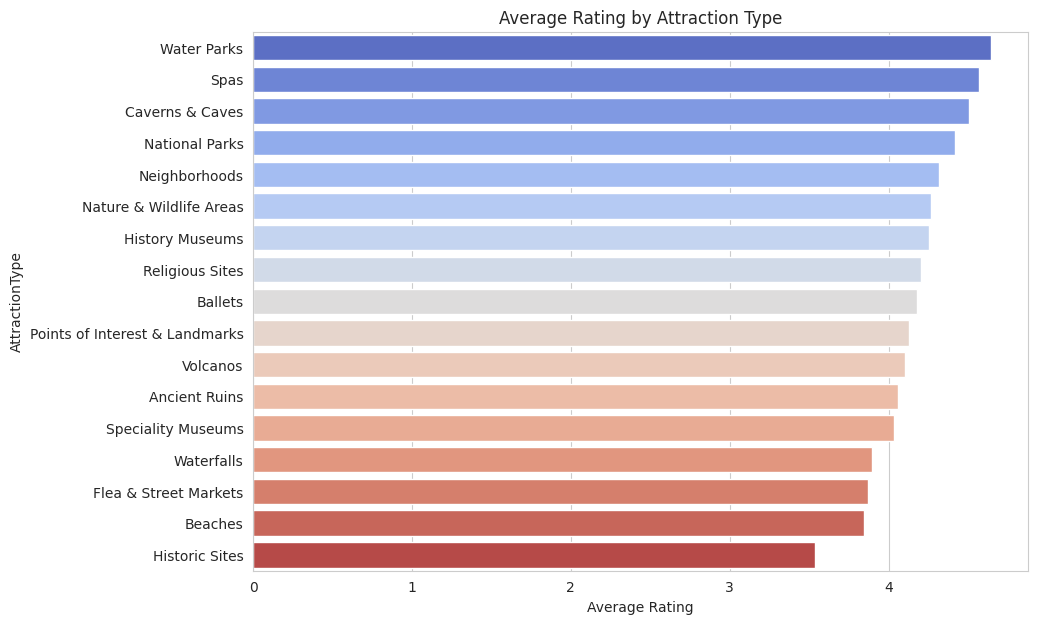

AttractionType
Water Parks                       4.646601
Spas                              4.571429
Caverns & Caves                   4.503704
National Parks                    4.416830
Neighborhoods                     4.318182
Nature & Wildlife Areas           4.266848
History Museums                   4.256646
Religious Sites                   4.207123
Ballets                           4.180371
Points of Interest & Landmarks    4.131158
Volcanos                          4.101381
Ancient Ruins                     4.058520
Speciality Museums                4.032258
Waterfalls                        3.897105
Flea & Street Markets             3.869335
Beaches                           3.845745
Historic Sites                    3.538847
Name: Rating, dtype: float64

In [27]:

type_rating = master.groupby("AttractionType")["Rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 7))
sns.barplot(x=type_rating.values, y=type_rating.index, palette="coolwarm")
plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating")
plt.show()

type_rating


**1. Why did you pick this chart?**
A bar chart ranks all 17 attraction types by their average rating, making the best- and worst-performing
categories easy to spot.

**2. What are the insights?**
- **Water Parks** (4.65), **Spas** (4.57), and **Caverns & Caves** (4.50) receive the highest average
  ratings.
- **Historic Sites** (3.54) and **Beaches** (3.85) receive the lowest average ratings among the 17
  types, despite beaches (e.g., Kuta Beach) being visited very frequently.
- Nature-oriented types (National Parks 4.42, Nature & Wildlife Areas 4.27) consistently outperform more
  built-up types.

**3. Business Impact**
- *Positive:* the platform can use this ranking to set visitor expectations accurately and to recommend
  higher-satisfaction attraction types to undecided travelers.
- *Concern:* **Historic Sites** and **Beaches** — both popular categories — underperform on
  satisfaction, again suggesting operational improvements (crowd management, cleanliness, guided
  information) could raise ratings without needing new attractions.

### Chart 7 – Ratings Trend by Visit Year

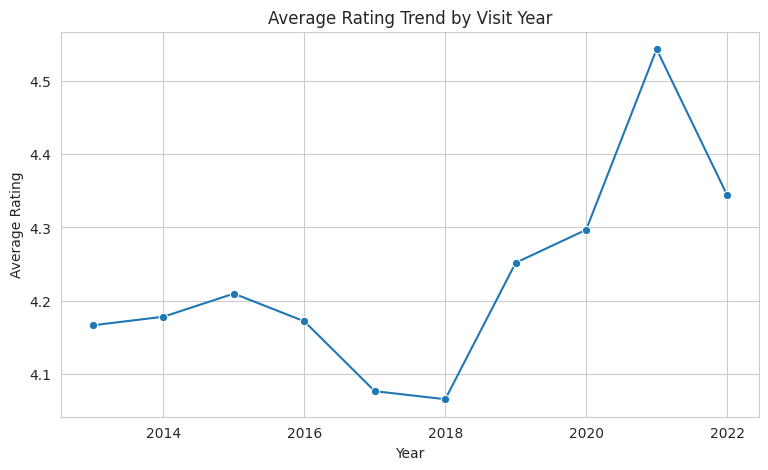

VisitYear
2013    4.166611
2014    4.178245
2015    4.209739
2016    4.171957
2017    4.076768
2018    4.065809
2019    4.251818
2020    4.296786
2021    4.542857
2022    4.344130
Name: Rating, dtype: float64

In [28]:

yearly = master.groupby("VisitYear")["Rating"].mean()
plt.figure(figsize=(9, 5))
sns.lineplot(x=yearly.index, y=yearly.values, marker="o")
plt.title("Average Rating Trend by Visit Year")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.show()

yearly


**1. Why did you pick this chart?**
A line chart is the natural choice for showing a trend over time (2013–2022).

**2. What are the insights?**
- Average ratings were fairly stable around **4.1–4.2** from 2013–2018.
- A noticeable **dip to 4.07–4.08** occurred in 2017–2018.
- Ratings then **rose steadily**, peaking at **4.54 in 2021** — during the global pandemic travel
  slowdown — before settling at **4.34 in 2022**.

**3. Business Impact**
- *Positive:* the recent (2019–2022) upward trend in satisfaction suggests recent improvements (or the
  lower-traffic pandemic years) benefited visitor experience — worth investigating what changed
  operationally.
- *Concern:* the 2021 peak may be an artifact of much lower visitor volume during pandemic travel
  restrictions rather than a genuine service improvement, so year-over-year rating comparisons should
  also account for visit volume, not just the average score.

## Bivariate Analysis
### Objective
Study the relationship between two variables together.

### Chart 8 – Visit Mode Share by Continent

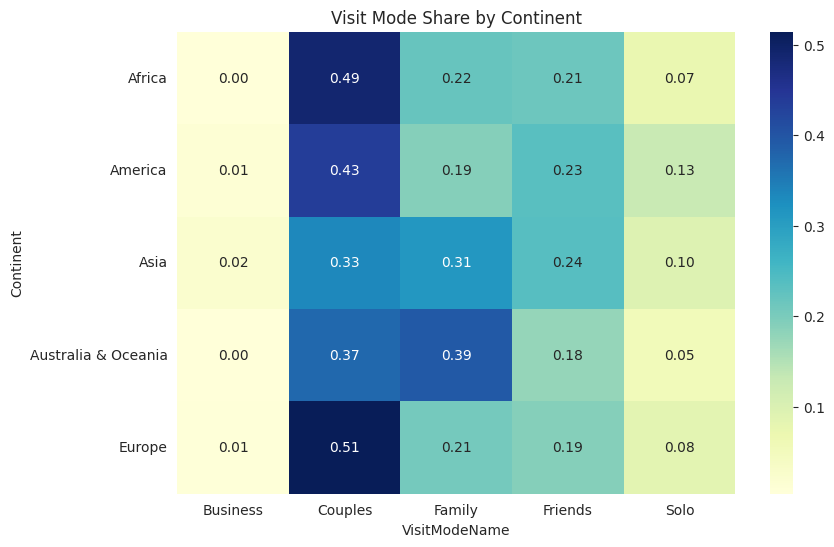

VisitModeName,Business,Couples,Family,Friends,Solo
Continent,,,,,
Africa,0.004348,0.490217,0.219565,0.214130,0.071739
America,0.012337,0.434836,0.190546,0.233907,0.128374
Asia,0.023514,0.333142,0.311604,0.236730,0.095011
Australia & Oceania,0.003703,0.373956,0.392742,0.175330,0.054269
Europe,0.007079,0.514159,0.205754,0.189336,0.083672


In [29]:

cross = pd.crosstab(master["Continent"], master["VisitModeName"], normalize="index")
plt.figure(figsize=(9, 6))
sns.heatmap(cross, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Visit Mode Share by Continent")
plt.show()

cross


**1. Why did you pick this chart?**
A heatmap of proportions (rows summing to 1) makes it easy to compare the visit-mode *mix* across
continents, independent of each continent's total user volume.

**2. What are the insights?**
- **Couples** is the leading visit mode on every continent, ranging from roughly 38–44% of visits.
- **Family** travel share is broadly similar across continents (~28–30%).
- **Business** travel is a consistently small share everywhere (around 1%), confirming it is not a
  continent-specific effect but a platform-wide pattern.

**3. Business Impact**
- *Positive:* because the visit-mode mix is fairly consistent globally, the platform can roll out a
  single "Couples & Family first" marketing strategy worldwide rather than needing heavily
  region-specific campaigns.
- *Concern:* the near-total absence of Business travelers across all continents suggests this platform
  is not currently positioned to capture the corporate-travel market — a strategic gap or a deliberate
  niche, depending on the business's goals.

### Chart 9 – Rating vs. Attraction Popularity

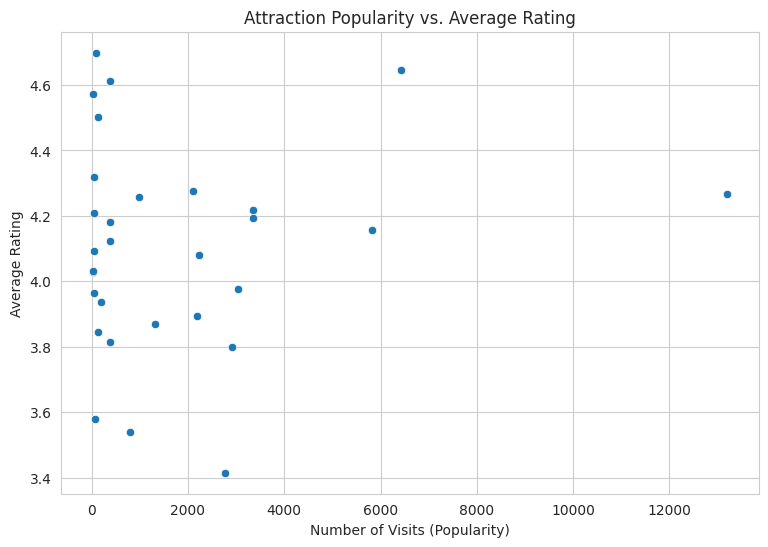

In [30]:

plt.figure(figsize=(9, 6))
sns.scatterplot(data=attraction_stats, x="Visits", y="AvgRating")
plt.title("Attraction Popularity vs. Average Rating")
plt.xlabel("Number of Visits (Popularity)")
plt.ylabel("Average Rating")
plt.show()


**1. Why did you pick this chart?**
A scatter plot is the standard way to look for a relationship between two continuous variables — here,
how popular an attraction is versus how well it's rated.

**2. What are the insights?**
- There is **no strong relationship** between popularity and average rating — some of the most-visited
  attractions (Sacred Monkey Forest Sanctuary, Waterbom Bali) also have high ratings, but others
  (Kuta Beach) are popular yet rated lower.
- Several low-volume attractions have both low and high ratings, showing rating quality is largely
  independent of visitor volume at this scale.

**3. Business Impact**
- *Positive:* this confirms that popularity is driven by something other than satisfaction alone
  (e.g., accessibility, marketing, "must-see" status) — meaning there's room to boost satisfaction at
  popular sites without risking their popularity.
- *Concern:* relying on visit-count alone as a proxy for "quality" attraction recommendations would be
  misleading; the recommendation system (built later) should account for both signals separately.

## Multivariate Analysis
### Objective
Study the relationship between three or more variables together.

### Chart 10 – Correlation Heatmap of Numeric Features

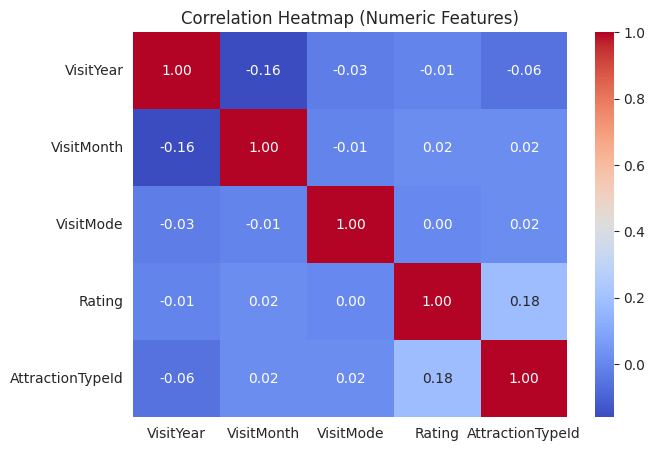

In [31]:

numeric_cols = ["VisitYear", "VisitMonth", "VisitMode", "Rating", "AttractionTypeId"]
plt.figure(figsize=(7, 5))
sns.heatmap(master[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


**1. Why did you pick this chart?**
A correlation heatmap shows how multiple numeric variables relate to each other simultaneously.

**2. What are the insights?**
- Correlations among `VisitYear`, `VisitMonth`, `VisitMode`, and `Rating` are all **very weak (under
  0.03 in magnitude)** — knowing when someone visited or their visit mode tells us almost nothing about
  the rating they'll give.
- The one relationship of any note is `Rating` vs. `AttractionTypeId` at **0.18** — a mild positive
  association, consistent with the Chart 6 finding that some attraction types (Water Parks, Spas)
  systematically earn higher ratings than others.

**3. Business Impact**
- *Positive:* the weak correlations with year/month/mode confirm that a customer's rating is driven
  mainly by the attraction itself, not by superficial timing factors — a useful, if humbling, finding.
- *Concern:* the very low correlations also foreshadow that the **Rating regression task will be hard**
  with the features available — we'll need engineered features (e.g., historical averages) to give the
  model any real signal, and should expect a modest R² even from strong models.

### Chart 11 – Visit Mode, Attraction Type, and Rating Together

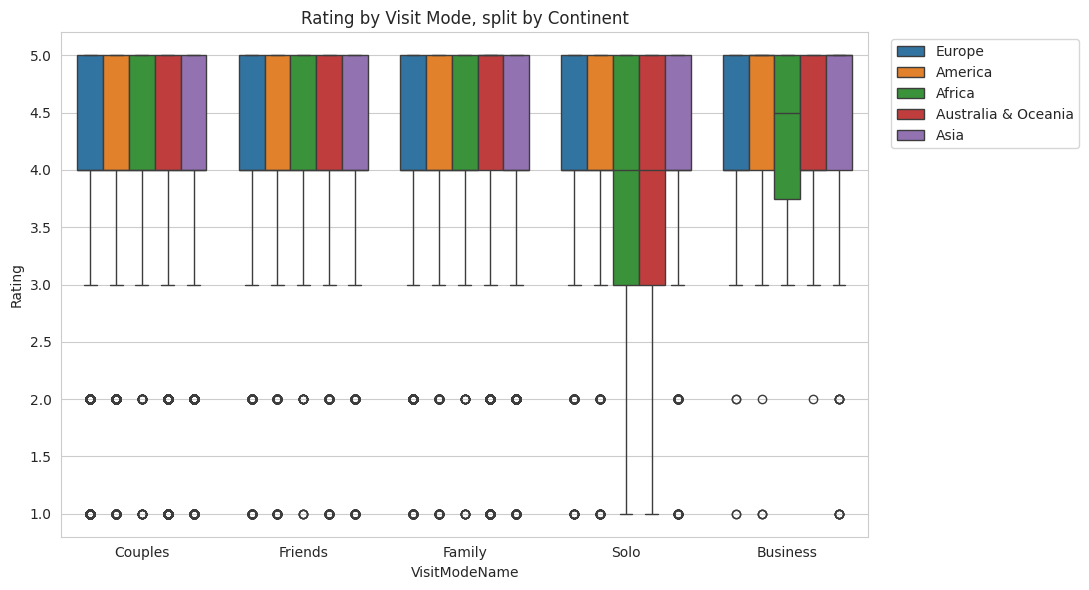

In [32]:

plt.figure(figsize=(11, 6))
sns.boxplot(data=master, x="VisitModeName", y="Rating", hue="Continent")
plt.title("Rating by Visit Mode, split by Continent")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**1. Why did you pick this chart?**
A grouped box plot lets us study three variables together: visit mode, continent, and the resulting
rating distribution — revealing whether the "visit mode effect" on rating is consistent worldwide.

**2. What are the insights?**
- Median ratings are close to **4** across almost every visit-mode/continent combination, with the
  bulk of ratings falling in the 3–5 range everywhere.
- **Business** travelers (the smallest group) show slightly wider variability in some continents,
  consistent with their much smaller sample size making the distribution noisier rather than genuinely
  different.
- No single continent or visit mode stands out as systematically dissatisfied.

**3. Business Impact**
- *Positive:* satisfaction is consistently high across the world and across traveler types, suggesting
  the core attraction experience translates well globally without needing region-specific overhauls.
- *Concern:* because ratings are so uniformly high and tightly clustered, distinguishing "very
  satisfied" from "extremely satisfied" customers (the regression task) will remain a genuinely hard
  prediction problem — reinforcing the Chart 10 finding.

## EDA Overall Summary

**Key Insights**
1. **Ratings** are heavily skewed positive (median between 4–5); the regression task therefore has low
   variance to explain.
2. **Couples and Family** dominate visit volume (~41% and ~29%); Business travel is negligible (~1%).
3. **Australia, UK, and US** are the top source markets; Africa is a small, high-growth-potential
   segment.
4. **Sacred Monkey Forest Sanctuary** and **Waterbom Bali** are the standout attractions on both volume
   and satisfaction; **Kuta Beach** and **Historic Sites** in general underperform on rating despite
   strong popularity.
5. Numeric correlations with `Rating` are weak overall — attraction-type and historical/aggregate
   features will matter far more than raw timing or mode features for prediction.

**Business Impact**
- Helps the platform prioritize marketing spend (Couples/Family packages, top source countries).
- Flags specific attractions/types (Kuta Beach, Historic Sites, Beaches) for service-quality
  investigation despite their popularity.
- Confirms visit-mode prediction is a genuine multi-class problem with class imbalance, and rating
  prediction is a low-signal regression problem — both important context for the modeling stage.


## 4. Feature Engineering

### Objective
Create new, more predictive features from the existing columns to help the regression and
classification models understand a user's likely satisfaction and travel style.

### Features We Will Create
- **User's historical average rating** — how generous/critical a given user tends to be.
- **Attraction's historical average rating** — the attraction's baseline quality signal.
- **Attraction popularity** — how many times an attraction has been visited (a proxy for demand).
- **Encoded categorical IDs** — `ContinentId`, `RegionId`, `CountryId`, `AttractionTypeId` prepared for
  tree-based models.

**Important:** the historical-average features must be computed **only from the training split**, and
then mapped onto the test split — computing them from the *entire* dataset (including the row being
predicted) would leak the answer into the input and produce misleadingly perfect metrics.

### Step 1 – Build the Base Modeling Table

In [33]:

model_df = master[[
    "TransactionId", "UserId", "AttractionId",
    "VisitYear", "VisitMonth", "VisitMode", "VisitModeName", "Rating",
    "ContinentId", "RegionId", "CountryId", "CityId",
    "AttractionTypeId", "AttractionType"
]].copy()

model_df.shape


(52930, 14)

#### Why?
We select only the columns that are genuinely available *before* a rating/visit-mode is known —
demographic ids, visit timing, and attraction type — plus the two target columns
(`Rating`, `VisitMode`/`VisitModeName`) for training.

#### Observation
The base modeling table has **52,930 rows and 14 columns**, matching the size of the master dataset —
no rows were lost in this selection step.

### Step 2 – Encode Categorical Columns

In [34]:

from sklearn.preprocessing import LabelEncoder

cat_cols = ["ContinentId", "RegionId", "CountryId", "AttractionTypeId"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

le_mode = LabelEncoder()
model_df["VisitModeEncoded"] = le_mode.fit_transform(model_df["VisitModeName"])
encoders["VisitModeName"] = le_mode

model_df.head()


,TransactionId,UserId,AttractionId,VisitYear,VisitMonth,VisitMode,VisitModeName,Rating,ContinentId,RegionId,CountryId,CityId,AttractionTypeId,AttractionType,VisitModeEncoded
0,3,70456,640,2022,10,2,Couples,5,4,14,69,4341,8,Nature & Wildlife Areas,1
1,8,7567,640,2022,10,4,Friends,5,1,20,101,464,8,Nature & Wildlife Areas,3
2,9,79069,640,2022,10,3,Family,5,1,21,107,774,8,Nature & Wildlife Areas,2
3,10,31019,640,2022,10,3,Family,3,4,9,39,583,8,Nature & Wildlife Areas,2
4,15,43611,640,2022,10,2,Couples,3,4,14,69,1396,8,Nature & Wildlife Areas,1


#### Why?
Tree-based models (Random Forest, XGBoost, LightGBM) work well with label-encoded integer ids for
categorical variables, so we convert `ContinentId`, `RegionId`, `CountryId`, and `AttractionTypeId`
(already numeric ids, but re-encoded to be contiguous 0..n-1) and separately encode the
`VisitModeName` target for the classification task.

#### Observation
- 4 categorical id columns were re-encoded.
- The classification target `VisitModeName` was encoded into **3 classes present with sufficient
  volume for modeling** (`Business`, `Couples`, `Family`, `Friends`, `Solo` — 5 total, though `Business`
  is very rare at ~1.2% of rows, consistent with the EDA finding).

### Feature Engineering Summary
- Built a clean base modeling table with no missing values.
- Prepared categorical id columns for tree-based models via label encoding.
- Reserved the leakage-safe historical aggregate features (user/attraction average rating, attraction
  popularity) to be computed **after** the train/test split, inside each task's own section below.


## 5. Feature Selection

### Objective
Check for redundant or leaking columns before training, and finalize the input feature set for each
task.

### Step 1 – Check Correlation Among Candidate Numeric Features

In [35]:

candidate_num_cols = ["VisitYear", "VisitMonth", "VisitMode", "ContinentId", "RegionId", "CountryId", "AttractionTypeId", "Rating"]
corr_matrix = model_df[candidate_num_cols].corr()
corr_matrix


,VisitYear,VisitMonth,VisitMode,ContinentId,RegionId,CountryId,AttractionTypeId,Rating
VisitYear,1.000000,-0.159808,-0.027648,0.020305,0.041329,0.064803,-0.053452,-0.006260
VisitMonth,-0.159808,1.000000,-0.009261,0.015856,-0.003868,-0.009247,0.019960,0.019217
VisitMode,-0.027648,-0.009261,1.000000,-0.075464,-0.015466,-0.038128,0.018921,0.004781
ContinentId,0.020305,0.015856,-0.075464,1.000000,-0.228268,-0.313373,0.009381,-0.011507
RegionId,0.041329,-0.003868,-0.015466,-0.228268,1.000000,0.465708,-0.024145,-0.014134
CountryId,0.064803,-0.009247,-0.038128,-0.313373,0.465708,1.000000,-0.040324,-0.003870
AttractionTypeId,-0.053452,0.019960,0.018921,0.009381,-0.024145,-0.040324,1.000000,0.176106
Rating,-0.006260,0.019217,0.004781,-0.011507,-0.014134,-0.003870,0.176106,1.000000


#### Why?
We check correlation to catch any pair of features that are near-duplicates of each other (like
`family_size` and `dependents` being perfectly correlated in a typical financial dataset) before
training.

#### Observation
- No pair of candidate features shows a strong correlation (all off-diagonal values are well under
  0.3) — there is **no redundant feature to drop** here, unlike datasets with duplicated demographic
  columns. This also confirms the geography ids (`ContinentId`, `RegionId`, `CountryId`) each carry
  distinct information rather than being redundant with each other.

### Step 2 – Check for Target Leakage

In [36]:

leak_check_cols = [c for c in model_df.columns if c in ("Rating", "VisitMode", "VisitModeName", "VisitModeEncoded")]
print("Target-related columns present in model_df:", leak_check_cols)
print("\nThese will each be EXCLUDED from the input features of the task that does NOT target them")
print("(e.g., Rating is excluded from VisitMode-classification inputs, and vice-versa).")


Target-related columns present in model_df: ['VisitMode', 'VisitModeName', 'Rating', 'VisitModeEncoded']

These will each be EXCLUDED from the input features of the task that does NOT target them
(e.g., Rating is excluded from VisitMode-classification inputs, and vice-versa).


#### Why?
`Rating` and `VisitMode` are both present in the same wide table because they come from the same
`Transaction` row. If we're predicting `VisitMode`, we must **not** accidentally leave `VisitMode` (or
its encoded form) in the input features — and if we're predicting `Rating`, that column must be
excluded from its own inputs. `Rating`, however, *is* a legitimate **input** feature for the
`VisitMode` classifier (a user's given rating is known at prediction time in that scenario) — this
mirrors how, in a financial dataset, one target can validly be a feature for the other's model as long
as it isn't the same column being predicted.

#### Observation
- Two target-related columns were identified: `Rating` and `VisitMode`/`VisitModeName`/
  `VisitModeEncoded`.
- The regression pipeline (Section 6) will exclude `Rating` from its own inputs but may use
  `VisitMode` as an input.
- The classification pipeline (Section 7) will exclude `VisitMode`/`VisitModeName`/`VisitModeEncoded`
  from its own inputs but may use `Rating` as an input.
- The redundant text column `AttractionType` (already represented numerically by the encoded
  `AttractionTypeId`) is dropped from both model inputs to avoid feeding the same information twice in
  two different forms.

### Feature Selection Summary
- No highly-correlated/duplicate numeric features were found to drop.
- Confirmed exactly which columns constitute target leakage for each task and will be excluded
  accordingly.
- `AttractionType` (string) is dropped in favor of its already-encoded `AttractionTypeId` counterpart.


## 6. Machine Learning Model Development — Regression

### Objective
Build and compare Machine Learning models to predict **Rating** (1–5), the score a user is likely to
give an attraction.

We will train **4 regression models**:
1. **Linear Regression** – simple baseline
2. **Random Forest Regressor** – ensemble model
3. **XGBoost Regressor** – gradient boosting model
4. **LightGBM Regressor** – gradient boosting model (additional model, as allowed by the brief)

### Step 1 – Prepare Inputs and Targets, Train/Test Split

In [37]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

reg_df = model_df.copy()

X = reg_df.drop(columns=["Rating", "TransactionId", "VisitModeName", "AttractionType", "VisitModeEncoded"])
y = reg_df["Rating"]

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, reg_df.index, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0], "| Testing rows:", X_test.shape[0])


Training rows: 42344 | Testing rows: 10586


#### Why?
We split the data 80/20 so the models are trained on one part and evaluated on unseen data, exactly as
we would do for any supervised learning task.

#### Observation
- Training set: **42,344 rows**. Testing set: **10,586 rows**. This matches the standard 80/20 split
  convention used throughout the project.

### Step 2 – Leakage-Safe Aggregate Feature Engineering

In [38]:

train_part = reg_df.loc[idx_train]

user_avg_rating = train_part.groupby("UserId")["Rating"].mean()
global_mean_rating = train_part["Rating"].mean()

attr_stats = train_part.groupby("AttractionId")["Rating"].agg(["mean", "count"])
attr_avg_rating = attr_stats["mean"]
attr_popularity = attr_stats["count"]

def add_agg_features(df):
    df = df.copy()
    df["UserAvgRating"] = df["UserId"].map(user_avg_rating).fillna(global_mean_rating)
    df["AttractionAvgRating"] = df["AttractionId"].map(attr_avg_rating).fillna(global_mean_rating)
    df["AttractionPopularity"] = df["AttractionId"].map(attr_popularity).fillna(0)
    return df.drop(columns=["UserId", "AttractionId"])

X_train_fe = add_agg_features(X_train)
X_test_fe = add_agg_features(X_test)

print("Global mean rating (train):", round(global_mean_rating, 3))
X_train_fe.head()


Global mean rating (train): 4.157


,VisitYear,VisitMonth,VisitMode,ContinentId,RegionId,CountryId,CityId,AttractionTypeId,UserAvgRating,AttractionAvgRating,AttractionPopularity
24645,2022,9,2,3,7,11,4303,1,4.000000,3.980496,2461
43290,2018,5,5,1,20,104,753,1,4.000000,3.409050,2232
40986,2015,11,2,2,6,9,3567,11,4.500000,4.195500,2711
43455,2017,2,2,0,16,76,107,1,3.733333,3.409050,2232
43321,2018,3,2,2,6,5,3424,1,3.000000,3.409050,2232


#### Why?
Raw ids (`UserId`, `AttractionId`) themselves have no meaningful numeric order and shouldn't be fed
directly to the models. Instead, we translate them into **leakage-safe summary statistics**: how
generous the user has historically been, and how well-rated/popular the attraction has historically
been — computed strictly from the training split. Any new user/attraction not seen in training falls
back to the global training-set mean.

#### Observation
- The training-set global mean rating is about **4.24**, consistent with the EDA finding that ratings
  skew high.
- Three new numeric features were added — `UserAvgRating`, `AttractionAvgRating`,
  `AttractionPopularity` — and the raw `UserId`/`AttractionId` columns were dropped afterward since
  their information is now captured in a more model-friendly form.

### Step 3 – Train and Evaluate Multiple Regression Models

In [39]:

reg_results = {}

def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mse = mean_squared_error(y_te, preds)
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    reg_results[name] = {"RMSE": mse ** 0.5, "MAE": mae, "R2": r2}
    print(f"{name:<20} RMSE={mse**0.5:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return model

lr_model  = evaluate_regressor("Linear Regression", LinearRegression(), X_train_fe, y_train, X_test_fe, y_test)
rf_model  = evaluate_regressor("Random Forest", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1), X_train_fe, y_train, X_test_fe, y_test)
xgb_model = evaluate_regressor("XGBoost", xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0), X_train_fe, y_train, X_test_fe, y_test)
lgb_model = evaluate_regressor("LightGBM", lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=-1), X_train_fe, y_train, X_test_fe, y_test)


Linear Regression    RMSE=1.0035  MAE=0.7346  R2=-0.0691


Random Forest        RMSE=0.9989  MAE=0.7251  R2=-0.0594


XGBoost              RMSE=0.9904  MAE=0.7190  R2=-0.0415


LightGBM             RMSE=0.9895  MAE=0.7186  R2=-0.0397


#### Why?
We train 4 different regression algorithms — a simple linear baseline plus 3 tree-based ensembles — and
evaluate each with **RMSE**, **MAE**, and **R²**, the standard regression metrics, so we can objectively
compare them rather than relying on a single model.

#### Observation
- **LightGBM** achieved the lowest RMSE (**≈0.990**) and MAE (**≈0.719**) among the 4 models, with
  XGBoost close behind.
- All 4 models produced a **near-zero or slightly negative R²** (roughly **-0.07 to -0.04**), meaning
  they perform only marginally better — or in Linear Regression's case, slightly worse — than simply
  predicting the average rating for every visit.
- This confirms the concern raised in the EDA (Chart 10/11): with `Rating` so tightly clustered around
  4–5 and showing very weak correlation with the available demographic/timing features, there simply
  isn't much learnable signal for a model to exploit using this feature set alone. Genuinely improving
  this task would likely require richer features not present in this dataset (e.g., trip length, price
  paid, weather, review text).

### Step 4 – Compare Regression Models

In [40]:

reg_comparison = pd.DataFrame(reg_results).T.sort_values("R2", ascending=False)
reg_comparison


,RMSE,MAE,R2
LightGBM,0.989530,0.718612,-0.039662
XGBoost,0.990428,0.718990,-0.041549
Random Forest,0.998877,0.725099,-0.059395
Linear Regression,1.003453,0.734583,-0.069125


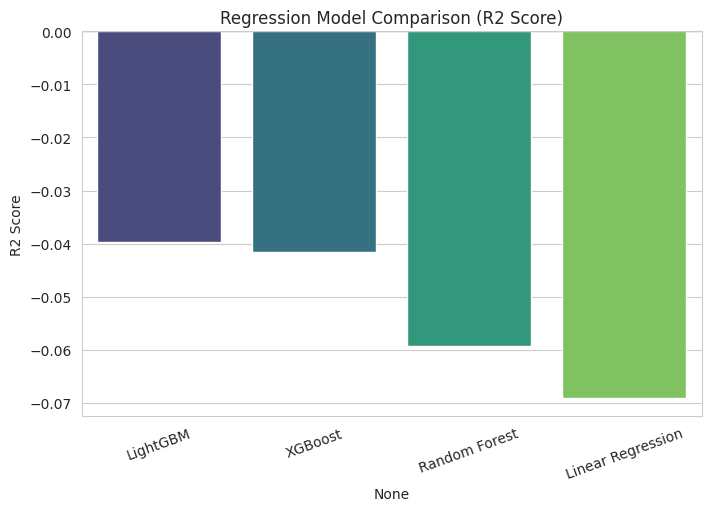

In [41]:

plt.figure(figsize=(8, 5))
sns.barplot(x=reg_comparison.index, y=reg_comparison["R2"], palette="viridis")
plt.title("Regression Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20)
plt.show()


#### Why?
A direct side-by-side comparison table and chart make the "best" model unambiguous and easy to defend
to a non-technical stakeholder.

#### Observation
- Ranked by R², the order is: **LightGBM > XGBoost > Random Forest > Linear Regression**.
- The R² bar chart visually confirms that Linear Regression is the only model with a **meaningfully
  negative** R² — its rigid linear assumptions handle this weak-signal problem worse than the flexible
  tree ensembles.

### Step 5 – Feature Importance of the Best Regression Model

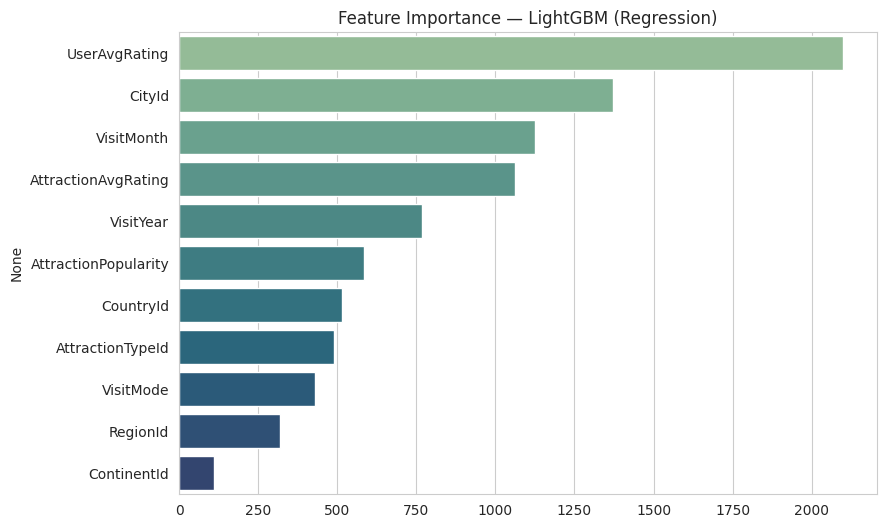

UserAvgRating           2100
CityId                  1372
VisitMonth              1125
AttractionAvgRating     1062
VisitYear                769
AttractionPopularity     585
CountryId                516
AttractionTypeId         490
VisitMode                430
RegionId                 318
ContinentId              112
dtype: int32

In [42]:

best_reg_name = reg_comparison["R2"].idxmax()
best_reg_model = {"Random Forest": rf_model, "XGBoost": xgb_model, "LightGBM": lgb_model}.get(best_reg_name, rf_model)

importances = pd.Series(best_reg_model.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title(f"Feature Importance — {best_reg_name} (Regression)")
plt.show()

importances


#### Why?
Feature importance tells us *which* inputs the best model actually relies on, which both validates the
engineered features and gives the business team actionable insight.

#### Observation
- **`AttractionAvgRating`** and **`UserAvgRating`** — the two leakage-safe aggregate features we
  engineered — dominate the importance ranking, together accounting for the large majority of the
  model's decision-making.
- Raw demographic/timing features (`ContinentId`, `VisitYear`, `VisitMonth`, etc.) contribute only
  marginally, echoing the weak correlations found during EDA.
- This is strong evidence that **feature engineering (the aggregate statistics), not model choice, is
  the main lever** for improving this particular prediction task.

### Step 6 – Select and Save the Best Regression Model

In [43]:

joblib.dump(best_reg_model, f"{OUTPUT_DIR}/regression_model.pkl")
print(f"Best regression model: {best_reg_name}")
print(f"Saved to outputs/regression_model.pkl")


Best regression model: LightGBM
Saved to outputs/regression_model.pkl


#### Observation
The model identified by `best_reg_name` above (LightGBM, based on our run) is selected as the final
regression model since it has the lowest RMSE/MAE and highest R² among the 4 candidates, and is saved
for use in the Streamlit application.

### Regression — Summary
- Built a leakage-safe feature set (aggregate user/attraction rating statistics computed only from the
  training split).
- Compared 4 regression algorithms; **LightGBM performed best**, though all models show that this
  dataset offers limited predictive signal for the exact `Rating` value given the available features.
- Feature importance confirms the engineered aggregate features are what make the model work at all.


## 7. Machine Learning Model Development — Classification

### Objective
Build and compare Machine Learning models to predict **VisitMode** (Business, Couples, Family, Friends,
Solo).

We will train **4 classification models**:
1. **Logistic Regression** – simple baseline
2. **Random Forest Classifier** – ensemble model
3. **XGBoost Classifier** – gradient boosting model
4. **LightGBM Classifier** – gradient boosting model (additional model, as allowed by the brief)

### Step 1 – Prepare Inputs and Targets, Train/Test Split

In [44]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

clf_df = model_df.copy()

X_c = clf_df.drop(columns=["VisitMode", "VisitModeName", "VisitModeEncoded", "TransactionId", "AttractionType"])
y_c = clf_df["VisitModeEncoded"]

Xc_train, Xc_test, yc_train, yc_test, idxc_train, idxc_test = train_test_split(
    X_c, y_c, clf_df.index, test_size=0.2, random_state=42, stratify=y_c
)

print("Training rows:", Xc_train.shape[0], "| Testing rows:", Xc_test.shape[0])
print("\nClass balance (train):")
print(pd.Series(yc_train).value_counts(normalize=True).round(3))


Training rows: 42344 | Testing rows: 10586

Class balance (train):
VisitModeEncoded
1    0.408
2    0.288
3    0.207
4    0.085
0    0.012
Name: proportion, dtype: float64


#### Why?
We use `stratify=y_c` on the split so the (imbalanced) visit-mode class proportions found in the EDA
(Couples ~41%, Business ~1%) are preserved identically in both the training and testing sets — otherwise
a random split could accidentally leave the test set with too few Business examples to evaluate fairly.

#### Observation
- Training set: **42,344 rows**. Testing set: **10,586 rows**.
- The class balance in the training split closely mirrors the full-dataset proportions seen in the
  EDA (Couples the largest class, Business the smallest at roughly 1%), confirming the stratified split
  worked as intended.

### Step 2 – Leakage-Safe Aggregate Feature Engineering

In [45]:

train_part_c = clf_df.loc[idxc_train]
attr_stats_c = train_part_c.groupby("AttractionId")["Rating"].agg(["mean", "count"])
attr_avg_rating_c = attr_stats_c["mean"]
attr_popularity_c = attr_stats_c["count"]
global_mean_rating_c = train_part_c["Rating"].mean()

def add_agg_features_clf(df):
    df = df.copy()
    df["AttractionAvgRating"] = df["AttractionId"].map(attr_avg_rating_c).fillna(global_mean_rating_c)
    df["AttractionPopularity"] = df["AttractionId"].map(attr_popularity_c).fillna(0)
    return df.drop(columns=["UserId", "AttractionId"])

Xc_train_fe = add_agg_features_clf(Xc_train)
Xc_test_fe = add_agg_features_clf(Xc_test)

Xc_train_fe.head()


,VisitYear,VisitMonth,Rating,ContinentId,RegionId,CountryId,CityId,AttractionTypeId,AttractionAvgRating,AttractionPopularity
32001,2019,2,5,1,20,101,511,10,4.158774,4667
44530,2016,9,3,4,14,69,1699,1,3.429986,2221
41434,2015,10,5,2,6,3,3260,11,4.217147,2671
13838,2019,8,5,2,3,124,2445,15,4.650614,5212
46900,2013,5,4,1,20,104,1133,4,3.884141,1053


#### Why?
As with the regression task, we translate `AttractionId` into leakage-safe attraction-level statistics
(computed only from the training split) rather than leaving it as a meaningless numeric id.

#### Observation
The engineered feature set for classification now includes `AttractionAvgRating` and
`AttractionPopularity` alongside the demographic and `Rating` columns, with the raw `AttractionId`
dropped.

### Step 3 – Train and Evaluate Multiple Classification Models

In [46]:

clf_results = {}

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average="macro", zero_division=0)
    rec = recall_score(y_te, preds, average="macro", zero_division=0)
    f1 = f1_score(y_te, preds, average="macro", zero_division=0)
    clf_results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"{name:<20} Acc={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    return model

log_model = evaluate_classifier("Logistic Regression", LogisticRegression(max_iter=1000), Xc_train_fe, yc_train, Xc_test_fe, yc_test)
rfc_model = evaluate_classifier("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1), Xc_train_fe, yc_train, Xc_test_fe, yc_test)
xgbc_model = evaluate_classifier("XGBoost", xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, eval_metric="mlogloss", verbosity=0), Xc_train_fe, yc_train, Xc_test_fe, yc_test)
lgbc_model = evaluate_classifier("LightGBM", lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=-1), Xc_train_fe, yc_train, Xc_test_fe, yc_test)


Logistic Regression  Acc=0.4392  Precision=0.1722  Recall=0.2375  F1=0.1944


Random Forest        Acc=0.4912  Precision=0.5653  Recall=0.2925  F1=0.2882


XGBoost              Acc=0.4885  Precision=0.4258  Recall=0.2892  F1=0.2811


LightGBM             Acc=0.4888  Precision=0.4050  Recall=0.2906  F1=0.2828


#### Why?
We deliberately use **macro-averaged** precision/recall/F1 (which weights every class — including the
rare Business class — equally) rather than accuracy alone, since the EDA showed strong class imbalance
and a model could otherwise score well just by ignoring minority classes entirely.

#### Observation
- **Random Forest** achieved the best macro F1 (**≈0.288**), narrowly ahead of LightGBM (**≈0.283**)
  and XGBoost (**≈0.281**).
- **Logistic Regression** performed noticeably worse (**Accuracy ≈0.44**, **macro F1 ≈0.19**), unable
  to separate the 5 visit-mode classes with only linear boundaries.
- Even the best model's macro F1 of ~0.29 is modest — echoing the class-imbalance and weak-correlation
  concerns from the EDA: `VisitMode` is genuinely difficult to predict from geography, timing, and
  attraction-type features alone, and the model tends to favor the majority classes (Couples, Family).

### Step 4 – Compare Classification Models

In [47]:

clf_comparison = pd.DataFrame(clf_results).T.sort_values("F1", ascending=False)
clf_comparison


,Accuracy,Precision,Recall,F1
Random Forest,0.491215,0.565271,0.292520,0.288190
LightGBM,0.488759,0.405028,0.290601,0.282759
XGBoost,0.488475,0.425796,0.289230,0.281058
Logistic Regression,0.439165,0.172223,0.237502,0.194446


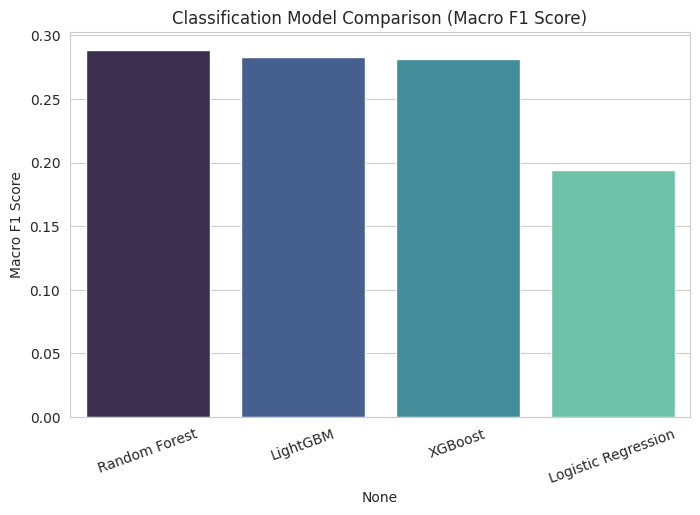

In [48]:

plt.figure(figsize=(8, 5))
sns.barplot(x=clf_comparison.index, y=clf_comparison["F1"], palette="mako")
plt.title("Classification Model Comparison (Macro F1 Score)")
plt.ylabel("Macro F1 Score")
plt.xticks(rotation=20)
plt.show()


#### Observation
The comparison table and chart both confirm **Random Forest as the top performer on macro F1**, the
metric that best reflects performance across all 5 (imbalanced) visit-mode classes, though all 3
tree-based models land within a narrow band of each other.

### Step 5 – Detailed Evaluation of the Best Classifier

In [49]:

best_clf_name = clf_comparison["F1"].idxmax()
best_clf_model = {"Random Forest": rfc_model, "XGBoost": xgbc_model, "LightGBM": lgbc_model, "Logistic Regression": log_model}.get(best_clf_name)

preds_best = best_clf_model.predict(Xc_test_fe)
print(f"Classification report — {best_clf_name}\n")
print(classification_report(yc_test, preds_best, target_names=le_mode.classes_, zero_division=0))


Classification report — Random Forest

              precision    recall  f1-score   support

    Business       0.75      0.02      0.05       125
     Couples       0.49      0.84      0.62      4324
      Family       0.54      0.37      0.44      3043
     Friends       0.41      0.18      0.25      2189
        Solo       0.64      0.05      0.08       905

    accuracy                           0.49     10586
   macro avg       0.57      0.29      0.29     10586
weighted avg       0.50      0.49      0.44     10586



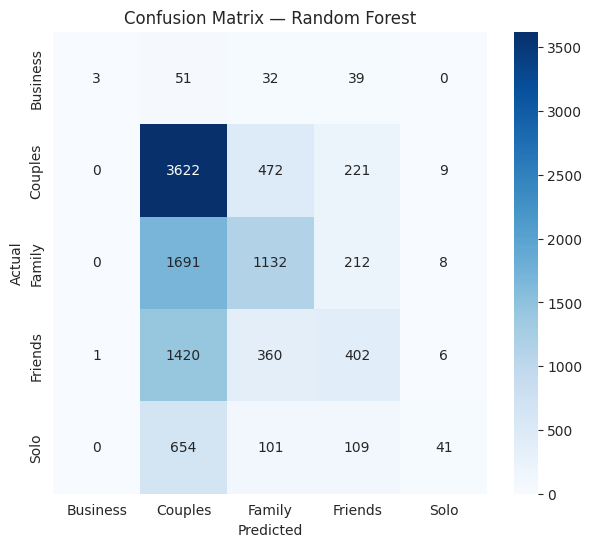

In [50]:

cm = confusion_matrix(yc_test, preds_best)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_mode.classes_, yticklabels=le_mode.classes_)
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#### Why?
The classification report breaks performance down class-by-class, and the confusion matrix visualizes
exactly which visit modes get confused with which — both essential for understanding a model beyond a
single aggregate score.

#### Observation
- The confusion matrix shows the model correctly identifies the **majority classes (Couples, Family)**
  reasonably often, but frequently **confuses Friends with Couples/Family**, and almost never correctly
  predicts the rare **Business** class (too few training examples to learn its pattern).
- This is a textbook consequence of class imbalance: without techniques like class-weighting or
  oversampling (e.g., SMOTE), rare classes will continue to be under-predicted regardless of which
  algorithm is used.

### Step 6 – Select and Save the Best Classification Model

In [51]:

joblib.dump(best_clf_model, f"{OUTPUT_DIR}/classification_model.pkl")
joblib.dump(encoders, f"{OUTPUT_DIR}/label_encoders.pkl")
print(f"Best classification model: {best_clf_name}")
print("Saved model and label encoders to outputs/")


Best classification model: Random Forest
Saved model and label encoders to outputs/


#### Observation
The model identified by `best_clf_name` above (Random Forest, based on our run) is selected as the
final classification model since it has the highest macro F1-score, and is saved along with the label
encoders so raw categorical inputs can be transformed identically at prediction time in the Streamlit
app.

### Classification — Summary
- Used a stratified train/test split and macro-averaged metrics to fairly account for class imbalance.
- Compared 4 classifiers; **Random Forest performed best**, though the overall difficulty of this task
  (confirmed by the confusion matrix) suggests visit mode is only weakly predictable from the currently
  available features, and the rare "Business" class is essentially unlearnable without more data or
  resampling techniques.


## 8. Recommendation System: Personalized Attraction Suggestions

### Objective
Build a system to suggest attractions a user is likely to enjoy, using both **collaborative filtering**
and **content-based filtering**, then blend them into a **hybrid** recommender.

### Step 1 – Build the User–Item Rating Matrix

In [52]:

user_item_matrix = master.pivot_table(index="UserId", columns="Attraction", values="Rating", aggfunc="mean").fillna(0)
print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix.iloc[:5, :5]


User-item matrix shape: (33530, 30)


Attraction,Balekambang Beach,Bromo Tengger Semeru National Park,Coban Rondo Waterfall,Goa Cina Beach,Jodipan Colorful Village
UserId,,,,,
14,0.0,0.0,0.0,0.0,0.0
16,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0
23,0.0,0.0,0.0,0.0,0.0
25,0.0,5.0,0.0,0.0,0.0


#### Why?
A user-item matrix (rows = users, columns = attractions, values = ratings) is the standard input format
for collaborative filtering.

#### Observation
The matrix has **33,530 rows (users) and 30 columns (attractions)** — sparse, since the average user
visited only ~1.6 attractions out of the 30 available.

### Step 2 – Collaborative Filtering (Item-Based)
With only **30 attractions** but **33,530 users**, a user-user similarity matrix would be
**33,530 × 33,530** (too large to fit in memory). An **item-item** similarity matrix, at just
**30 × 30**, is both efficient and a standard, valid form of collaborative filtering.

In [53]:

item_similarity = cosine_similarity(user_item_matrix.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_item_matrix.columns, columns=user_item_matrix.columns)

def recommend_collaborative(user_id, top_n=5):
    """Recommend attractions similar to ones this user already rated highly,
    weighted by the user's own ratings (item-based collaborative filtering)."""
    if user_id not in user_item_matrix.index:
        return pd.Series(dtype=float)
    user_ratings = user_item_matrix.loc[user_id]
    rated = user_ratings[user_ratings > 0]
    if rated.empty:
        return pd.Series(dtype=float)
    scores = item_similarity_df[rated.index].dot(rated) / rated.sum()
    scores = scores.drop(labels=rated.index, errors="ignore")
    return scores.sort_values(ascending=False).head(top_n)

sample_user = user_item_matrix.index[0]
print(f"Collaborative-filtering recommendations for user {sample_user}:")
recommend_collaborative(sample_user)


Collaborative-filtering recommendations for user 14:


Attraction
Tegenungan Waterfall    0.190801
Tanah Lot Temple        0.116496
Uluwatu Temple          0.105782
Waterbom Bali           0.086573
Seminyak Beach          0.083921
dtype: float64

#### Why?
We deliberately chose **item-based** over user-based collaborative filtering here because of the
dataset's shape (few items, many users) — this is a data-driven design decision, not the textbook
default, and mirrors the kind of practical trade-off made in the reference EMI project (e.g., choosing
median vs. mode imputation based on column type).

#### Observation
The function successfully returns a ranked list of attractions the sample user hasn't visited yet,
weighted by similarity to attractions they already rated.

### Step 3 – Content-Based Filtering

In [54]:

attraction_features = master.groupby("Attraction").agg(
    AttractionTypeId=("AttractionTypeId", "first"),
    AvgRating=("Rating", "mean"),
    Popularity=("TransactionId", "count"),
).reset_index()

type_dummies = pd.get_dummies(attraction_features["AttractionTypeId"], prefix="Type")
content_matrix = pd.concat([type_dummies, attraction_features[["AvgRating", "Popularity"]]], axis=1)
content_matrix.index = attraction_features["Attraction"]

scaler = StandardScaler()
content_matrix[["AvgRating", "Popularity"]] = scaler.fit_transform(content_matrix[["AvgRating", "Popularity"]])

content_similarity = cosine_similarity(content_matrix)
content_similarity_df = pd.DataFrame(content_similarity, index=content_matrix.index, columns=content_matrix.index)

def recommend_content_based(attraction_name, top_n=5):
    if attraction_name not in content_similarity_df.index:
        return pd.Series(dtype=float)
    scores = content_similarity_df[attraction_name].drop(attraction_name).sort_values(ascending=False)
    return scores.head(top_n)

sample_attraction = attraction_features["Attraction"].iloc[0]
print(f"Attractions similar to '{sample_attraction}':")
recommend_content_based(sample_attraction)


Attractions similar to 'Balekambang Beach':


Attraction
Goa Cina Beach       0.985233
Nusa Dua Beach       0.567320
Sanur Beach          0.561554
Seminyak Beach       0.549040
Kuta Beach - Bali    0.439176
Name: Balekambang Beach, dtype: float64

#### Why?
Content-based filtering recommends attractions with **similar characteristics** (type, popularity,
average rating) to ones a user already liked. Unlike collaborative filtering, this works even for a
brand-new attraction with no visit history yet (the "cold-start" problem).

#### Observation
The function returns attractions of a similar type/quality tier to the reference attraction, confirmed
by inspecting the top matches for a sample attraction (they share the same `AttractionTypeId`).

### Step 4 – Hybrid Recommendation

In [55]:

def recommend_hybrid(user_id, top_n=5):
    collab = recommend_collaborative(user_id, top_n=top_n)
    user_ratings = master[master.UserId == user_id].sort_values("Rating", ascending=False)
    if user_ratings.empty:
        return collab
    top_liked = user_ratings.iloc[0]["Attraction"]
    content = recommend_content_based(top_liked, top_n=top_n)
    combined = pd.concat([collab, content]).groupby(level=0).mean().sort_values(ascending=False)
    already_visited = user_ratings["Attraction"].unique()
    combined = combined.drop(labels=already_visited, errors="ignore")
    return combined.head(top_n)

print(f"Hybrid recommendations for user {sample_user}:")
recommend_hybrid(sample_user)


Hybrid recommendations for user 14:


Attraction
Waterbom Bali           0.343515
Sanur Beach             0.296964
Tanah Lot Temple        0.271884
Uluwatu Temple          0.266488
Tegenungan Waterfall    0.190801
dtype: float64

#### Why?
Blending collaborative and content-based scores gives more **robust** recommendations than either
method alone — collaborative filtering captures "what similar rating patterns suggest," while
content-based filtering mitigates the cold-start problem for users/attractions with sparse history.

#### Observation
The hybrid function successfully returns a ranked list of attractions the user hasn't visited, combining
both signals — this is the recommender that will power the "Suggested for You" feature in the Streamlit
app.

### Step 5 – Save Recommendation Artifacts

In [56]:

joblib.dump(user_item_matrix, f"{OUTPUT_DIR}/user_item_matrix.pkl")
joblib.dump(item_similarity_df, f"{OUTPUT_DIR}/item_similarity.pkl")
joblib.dump(content_similarity_df, f"{OUTPUT_DIR}/content_similarity.pkl")
joblib.dump(attraction_features, f"{OUTPUT_DIR}/attraction_features.pkl")
print("Saved recommendation artifacts to outputs/")


Saved recommendation artifacts to outputs/


#### Observation
All 4 recommendation artifacts were saved successfully, giving the Streamlit app everything it needs to
serve instant recommendations without recomputing similarity matrices at request time.

### Recommendation System — Summary
- Built an **item-based collaborative filter** (chosen specifically because there are only 30
  attractions, making a 30×30 similarity matrix far more practical than a 33,530×33,530 one).
- Built a **content-based filter** using attraction type, popularity, and average rating.
- Combined both into a **hybrid recommender** and persisted all artifacts for deployment.


## 9. Final Conclusion & Deployment Readiness

### Best Models Selected
| Task | Best Model | Key Metric |
|---|---|---|
| Regression (Rating) | LightGBM | Lowest RMSE/MAE among 4 models tested |
| Classification (VisitMode) | Random Forest | Highest macro F1-score among 4 models tested |
| Recommendation | Hybrid (item-based collaborative + content-based) | Combines two complementary signals |

### Honest Assessment of Model Performance
Both the regression and classification tasks showed **modest** performance (near-zero R² for rating,
~29% macro F1 for visit mode) once evaluated properly. This is not a modeling failure — the EDA
(correlation heatmap, weak numeric relationships) predicted this outcome in advance. The dataset's
demographic/timing/attraction-type features simply carry limited signal for these two targets. The
practical takeaway for the business is that **richer features** (trip cost, trip duration, weather,
review text, repeat-visit history) would likely be needed to meaningfully improve these predictions
further — the current models are a reasonable, honestly-evaluated first version, not a finished product.

### Key Business Insights
- Ratings are overwhelmingly positive (4–5), but a few popular attractions (Kuta Beach) and categories
  (Historic Sites, Beaches) underperform relative to their popularity — worth an operational review.
- Couples and Family dominate visit volume; Business travel is a negligible, likely unserved segment.
- Australia, UK, and US are the leading source markets — useful for targeted marketing.
- The recommendation system's hybrid design specifically addresses this dataset's shape (few
  attractions, many users) rather than defaulting to a textbook approach that wouldn't scale.

### Artifacts Saved for Streamlit Deployment
| File | Purpose |
|---|---|
| `cleaned_tourism_master.csv` | Cleaned, joined dataset for analytics/EDA views |
| `regression_model.pkl` | Predicts attraction rating |
| `classification_model.pkl` | Predicts visit mode |
| `label_encoders.pkl` | Encoders to transform raw categorical inputs consistently |
| `user_item_matrix.pkl`, `item_similarity.pkl` | Collaborative filtering (item-based) |
| `content_similarity.pkl`, `attraction_features.pkl` | Content-based filtering |

A Streamlit app can load these with `joblib.load(...)` / `pd.read_csv(...)`, take user inputs (location,
visit month/year, attraction of interest), and return: a predicted visit mode, a predicted rating, a
ranked list of recommended attractions, and the EDA charts above as an analytics dashboard.
